<a href="https://colab.research.google.com/github/InvestitoreComune/analysis/blob/main/fondi_vs_etf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Scarico dati storici IWDA.AS da Yahoo Finance...


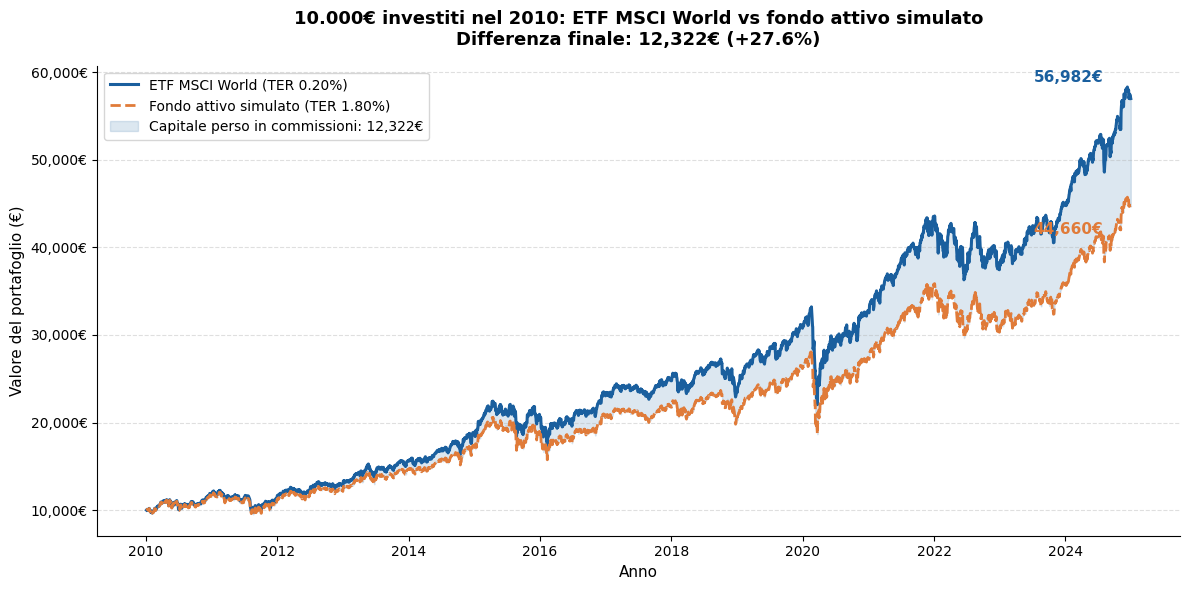


Grafico 1 salvato: grafico1_fondi_vs_etf.png
  ETF finale:   56,982€
  Fondo finale: 44,660€
  Differenza:   12,322€


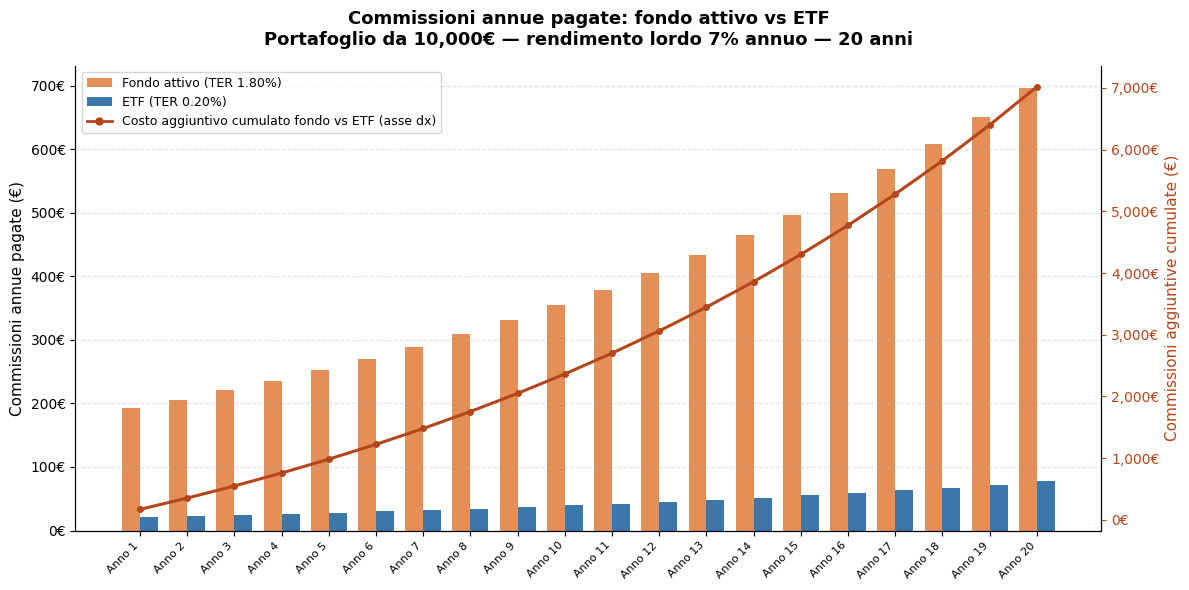


Grafico 2 salvato: grafico2_commissioni_annue.png
  Totale commissioni aggiuntive su 20 anni: 7,018€
  Commissioni annue anno 1  — fondo: 193€  | ETF: 21€
  Commissioni annue anno 20 — fondo: 697€ | ETF: 77€


In [1]:
"""
Fondi comuni vs ETF: confronto visivo con dati reali
Compatibile con Google Colab - eseguire le celle in ordine

Produce due grafici:
  grafico1_fondi_vs_etf.png  — Crescita di 10.000€: ETF vs fondo attivo simulato
  grafico2_commissioni_annue.png — Commissioni annue pagate su portafoglio da 10.000€
"""

# ── Installazione (necessaria su Colab) ──────────────────────────────────────
# !pip install yfinance matplotlib pandas numpy

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import Patch

# ── PARAMETRI MODIFICABILI ───────────────────────────────────────────────────
TICKER         = "IWDA.AS"          # iShares Core MSCI World, Euronext Amsterdam
START          = "2010-01-01"
END            = "2024-12-31"
CAPITALE       = 10_000             # €

TER_ETF        = 0.0020             # 0,20% annuo (già incorporato nel prezzo IWDA)
TER_FONDO      = 0.0180             # 1,80% annuo (TER medio fondo attivo bancario IT)
TER_DIFF       = TER_FONDO - TER_ETF   # 1,60% aggiuntivo annuo per il fondo


# ══════════════════════════════════════════════════════════════════════════════
# GRAFICO 1 — Crescita del capitale nel tempo
# ══════════════════════════════════════════════════════════════════════════════

print("Scarico dati storici IWDA.AS da Yahoo Finance...")
dati = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)

if dati.empty:
    raise ValueError(f"Nessun dato ricevuto per {TICKER}. Verifica la connessione o il ticker.")

prezzi = dati["Close"].squeeze().dropna()

# Curva ETF: normalizzo il prezzo a 10.000€ al primo giorno
valore_etf = (prezzi / prezzi.iloc[0]) * CAPITALE

# Curva Fondo: applico il TER aggiuntivo giorno per giorno
# La penalizzazione giornaliera è approssimata come TER_DIFF / 252 (giorni trading)
rendimenti_giornalieri = prezzi.pct_change().fillna(0)
penalizzazione_giornaliera = TER_DIFF / 252

rendimenti_fondo = rendimenti_giornalieri - penalizzazione_giornaliera
valore_fondo = CAPITALE * (1 + rendimenti_fondo).cumprod()

# Valori finali
val_etf_finale  = valore_etf.iloc[-1]
val_fondo_finale = valore_fondo.iloc[-1]
differenza      = val_etf_finale - val_fondo_finale

# ── Plot ─────────────────────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(valore_etf.index,  valore_etf.values,  color="#1a5f9e", linewidth=2.2,
         label=f"ETF MSCI World (TER {TER_ETF*100:.2f}%)")
ax1.plot(valore_fondo.index, valore_fondo.values, color="#e07b39", linewidth=2.0,
         linestyle="--", label=f"Fondo attivo simulato (TER {TER_FONDO*100:.2f}%)")

ax1.fill_between(
    valore_etf.index,
    valore_fondo.values,
    valore_etf.values,
    alpha=0.15,
    color="#1a5f9e",
    label=f"Capitale perso in commissioni: {differenza:,.0f}€"
)

# Annotazioni finali
anno_fine = valore_etf.index[-1]
ax1.annotate(
    f"{val_etf_finale:,.0f}€",
    xy=(anno_fine, val_etf_finale),
    xytext=(-70, 12),
    textcoords="offset points",
    fontsize=11, fontweight="bold", color="#1a5f9e"
)
ax1.annotate(
    f"{val_fondo_finale:,.0f}€",
    xy=(anno_fine, val_fondo_finale),
    xytext=(-70, -20),
    textcoords="offset points",
    fontsize=11, fontweight="bold", color="#e07b39"
)

ax1.set_title(
    f"10.000€ investiti nel 2010: ETF MSCI World vs fondo attivo simulato\n"
    f"Differenza finale: {differenza:,.0f}€ (+{differenza/val_fondo_finale*100:.1f}%)",
    fontsize=13, fontweight="bold", pad=15
)
ax1.set_xlabel("Anno", fontsize=11)
ax1.set_ylabel("Valore del portafoglio (€)", fontsize=11)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}€"))
ax1.legend(fontsize=10, loc="upper left")
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("grafico1_fondi_vs_etf.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nGrafico 1 salvato: grafico1_fondi_vs_etf.png")
print(f"  ETF finale:   {val_etf_finale:,.0f}€")
print(f"  Fondo finale: {val_fondo_finale:,.0f}€")
print(f"  Differenza:   {differenza:,.0f}€")


# ══════════════════════════════════════════════════════════════════════════════
# GRAFICO 2 — Commissioni annue pagate (simulazione teorica a 7% lordo, 20 anni)
# ══════════════════════════════════════════════════════════════════════════════

RENDIMENTO_LORDO = 0.07
ANNI = 20

anni     = np.arange(1, ANNI + 1)
capitale = CAPITALE * (1 + RENDIMENTO_LORDO) ** anni   # patrimonio a fine anno

commissioni_fondo = capitale * TER_FONDO
commissioni_etf   = capitale * TER_ETF
diff_annua        = commissioni_fondo - commissioni_etf
diff_cumulativa   = np.cumsum(diff_annua)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(12, 6))
ax3 = ax2.twinx()

larghezza = 0.38
x = np.arange(ANNI)

bar_fondo = ax2.bar(x - larghezza / 2, commissioni_fondo, larghezza,
                    label=f"Fondo attivo (TER {TER_FONDO*100:.2f}%)",
                    color="#e07b39", alpha=0.85)
bar_etf   = ax2.bar(x + larghezza / 2, commissioni_etf,   larghezza,
                    label=f"ETF (TER {TER_ETF*100:.2f}%)",
                    color="#1a5f9e", alpha=0.85)

linea, = ax3.plot(anni - 1, diff_cumulativa, color="#b5451b", linewidth=2.2,
                  linestyle="-", marker="o", markersize=4,
                  label="Totale commissioni aggiuntive cumulate (asse dx)")

ax2.set_xticks(x)
ax2.set_xticklabels([f"Anno {a}" for a in anni], rotation=45, ha="right", fontsize=8)
ax2.set_ylabel("Commissioni annue pagate (€)", fontsize=11)
ax3.set_ylabel("Commissioni aggiuntive cumulate (€)", fontsize=11, color="#b5451b")
ax3.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}€"))
ax3.tick_params(axis="y", colors="#b5451b")
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}€"))

ax2.set_title(
    f"Commissioni annue pagate: fondo attivo vs ETF\n"
    f"Portafoglio da {CAPITALE:,}€ — rendimento lordo {RENDIMENTO_LORDO*100:.0f}% annuo — 20 anni",
    fontsize=13, fontweight="bold", pad=15
)

legend_elementi = [
    Patch(facecolor="#e07b39", alpha=0.85, label=f"Fondo attivo (TER {TER_FONDO*100:.2f}%)"),
    Patch(facecolor="#1a5f9e", alpha=0.85, label=f"ETF (TER {TER_ETF*100:.2f}%)"),
    plt.Line2D([0], [0], color="#b5451b", linewidth=2, marker="o", markersize=5,
               label="Costo aggiuntivo cumulato fondo vs ETF (asse dx)")
]
ax2.legend(handles=legend_elementi, fontsize=9, loc="upper left")
ax2.grid(axis="y", linestyle="--", alpha=0.35)
ax2.spines[["top"]].set_visible(False)
ax3.spines[["top"]].set_visible(False)

plt.tight_layout()
plt.savefig("grafico2_commissioni_annue.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nGrafico 2 salvato: grafico2_commissioni_annue.png")
print(f"  Totale commissioni aggiuntive su 20 anni: {diff_cumulativa[-1]:,.0f}€")
print(f"  Commissioni annue anno 1  — fondo: {commissioni_fondo[0]:,.0f}€  | ETF: {commissioni_etf[0]:,.0f}€")
print(f"  Commissioni annue anno 20 — fondo: {commissioni_fondo[-1]:,.0f}€ | ETF: {commissioni_etf[-1]:,.0f}€")
